# California Housing Dataset Preprocessing
Preparing your data is an essential step when building an AI or machine learning model. This notebook walks you step-by-step through the basic investigation preprocessing tasks needed to clean and transform the California Housing dataset. In the next notebook, we will use this processed data to build our first model.

## Import Required Libraries

We begin by importing the Python libraries we'll need for data handling and visualization.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import os

## 1. Read the California Housing Dataset

We'll read the dataset (housing.csv) and save it as a DataFrame (df).

In [10]:
FileName = "housing.csv"
	
base_dir = os.getcwd()
path = os.path.join(base_dir, FileName)

print(path)

#read data
DataFrame = pd.read_csv(path)

# investigate the data
print(DataFrame)

c:\Users\Mathijs\Documents\GitHub\Toegepaste_AI\housing.csv
       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -122.23     37.88                41.0        880.0           129.0   
1        -122.22     37.86                21.0       7099.0          1106.0   
2        -122.24     37.85                52.0       1467.0           190.0   
3        -122.25     37.85                52.0       1274.0           235.0   
4        -122.25     37.85                52.0       1627.0           280.0   
...          ...       ...                 ...          ...             ...   
20635    -121.09     39.48                25.0       1665.0           374.0   
20636    -121.21     39.49                18.0        697.0           150.0   
20637    -121.22     39.43                17.0       2254.0           485.0   
20638    -121.32     39.43                18.0       1860.0           409.0   
20639    -121.24     39.37                16.0       2785.0           6

## 2. Explore the Dataset

Let's inspect the dataset — its shape, columns, missing values, and basic information.  

**Hint:**  `shape`, and `head()`, `isnull().sum()`, `info()` might be useful here

In [11]:
# Shape of the dataset (rows, columns)
print("Shape of dataset:")
print(DataFrame.shape)

Shape of dataset:
(20640, 10)


In [12]:
# First 5 rows
print("\nFirst 5 rows:")
print(DataFrame.head())


First 5 rows:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  house_value ocean_proximity  
0       322.0       126.0         8.3252     452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014     358500.0        NEAR BAY  
2       496.0       177.0         7.2574     352100.0        NEAR BAY  
3       558.0       219.0         5.6431     341300.0        NEAR BAY  
4       565.0       259.0         3.8462     342200.0        NEAR BAY  


In [13]:
# Column names
print("\nColumn names:")
print(DataFrame.columns)


Column names:
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'house_value', 'ocean_proximity'],
      dtype='object')


In [14]:
# Missing values in each column
print("\nMissing values:")
print(DataFrame.isnull().sum())


Missing values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
house_value             0
ocean_proximity         0
dtype: int64


In [15]:
# General information about the dataset
print("\nDataset info:")
print(DataFrame.info())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   house_value         20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None


In [16]:
# Basic statistical summary for numerical columns
print("\nStatistical summary:")
print(DataFrame.describe())


Statistical summary:
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.000000  20640.000000  20640.000000   20640.000000   
mean       537.870553   1425.476744    499.539680       3.870671   
std        421.385070   1132.462122    382.329753       1.899822   
min          1.000000      3.000000      1.000000       0.499900  

What is the data type of each column, and does the dataset contain any missing values? If so, in which columns?

In [ ]:
"""
dtype = int64
its missing 207 values in total bedrooms
"""

## 3. Remove Columns

Next week, we want to build a regression model. Regression models cannot handle missing values or non-numeric columns. Therefore, we need to remove any columns that contain missing values or non-numeric data such as text. Make sure to save the filtered data in a new variable or overwrite the existing one.

In [17]:
# Keep only numeric columns
DataFrame = DataFrame.select_dtypes(include=['number'])

# Remove columns that contain missing values
DataFrame = DataFrame.dropna(axis=1)

# Check the remaining columns
print("Remaining columns:")
print(DataFrame.columns)

# Check the new shape
print("\nNew shape:")
print(DataFrame.shape)

# Preview cleaned dataset
print("\nCleaned dataset preview:")
print(DataFrame.head())


Remaining columns:
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'population', 'households', 'median_income', 'house_value'],
      dtype='object')

New shape:
(20640, 8)

Cleaned dataset preview:
   longitude  latitude  housing_median_age  total_rooms  population  \
0    -122.23     37.88                41.0        880.0       322.0   
1    -122.22     37.86                21.0       7099.0      2401.0   
2    -122.24     37.85                52.0       1467.0       496.0   
3    -122.25     37.85                52.0       1274.0       558.0   
4    -122.25     37.85                52.0       1627.0       565.0   

   households  median_income  house_value  
0       126.0         8.3252     452600.0  
1      1138.0         8.3014     358500.0  
2       177.0         7.2574     352100.0  
3       219.0         5.6431     341300.0  
4       259.0         3.8462     342200.0  


What are other ways you could have handled missing values?

In [ ]:
"""
instead of removing the unwanted data, you can also just ignore it
"""

## 4. Visualize Relationships

We'll start by plotting **median_income vs. house_value** in a scatterplot to see if there’s a visible relationship.

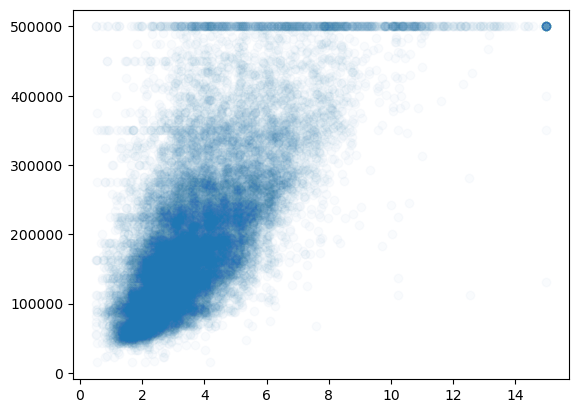

In [26]:
x = DataFrame["median_income"]
y = DataFrame["house_value"]

plt.scatter(x, y, alpha=0.025)

## Interpret the Plot
Do you see a relationship? If we want to make a prediction of the house value based on the median income, how good do you expect this to be?

In [ ]:
"""
i agree with this relationship because if you earn more, you can buy more expensive stuff, and not everyone is rich, so the cheaper thing is more densly populated

it looks like its in between 2 exponential lines
and of course a line at the very top because the data sees everything above 500000 as 500000

i would say you can make accurate decisions using this data
"""

## 5: Define Target Variable and Training Data

We'll define our target variable y. The target variable contains the values we want to predict, in this case the house_value. We need to store it in an extra variable y and drop it from the other data (training data). It is common to call the training data X.

## 6. Scale Training Data
Scaling data is an essential step in many AI workflows. Scaling is the process of transforming columns (features) so they share a similar numerical range, ensuring that no feature dominates the learning algorithm due to its magnitude. 
For example, if one feature ranges from 1–10 (e.g., HouseAge)
and another ranges from 1,000–100,000 (e.g., Population), the model might treat the larger-scale feature as more important simply because of its magnitude—not because it truly matters more.  

**Hint:**  Use `StandardScaler()`, to create a StandardScaler object and apply `fit_transform()` on the data with the scaler object.



Look at the scaled data. How did the numbers change?